In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de estilo académico para LaTeX
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({
    "figure.autolayout": True,
    "savefig.dpi": 300, # Alta resolución para impresión
    "savefig.format": "pdf" # El mejor formato para LaTeX
})

# Rutas
DIR_DATOS = "../data/processed/"
DIR_GRAFICOS = "../data/figures/"
os.makedirs(DIR_GRAFICOS, exist_ok=True)

# Cargar los datos que ya consolidamos
df_demanda = pd.read_csv(os.path.join(DIR_DATOS, "demanda_municipal_consolidada.csv"))
df_formal = pd.read_csv(os.path.join(DIR_DATOS, "oferta_formal_pcu.csv"))

print(f"Demanda cargada: {df_demanda.shape[0]} municipios.")
print(f"Oferta Formal cargada: {df_formal.shape[0]} polígonos PCU.")

Demanda cargada: 2392 municipios.
Oferta Formal cargada: 1857 polígonos PCU.


C:\Users\cesar\AppData\Local\Temp\ipykernel_40544\2544460979.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Pct_Mujeres_Real', y='estado', data=top_peores, palette="magma")


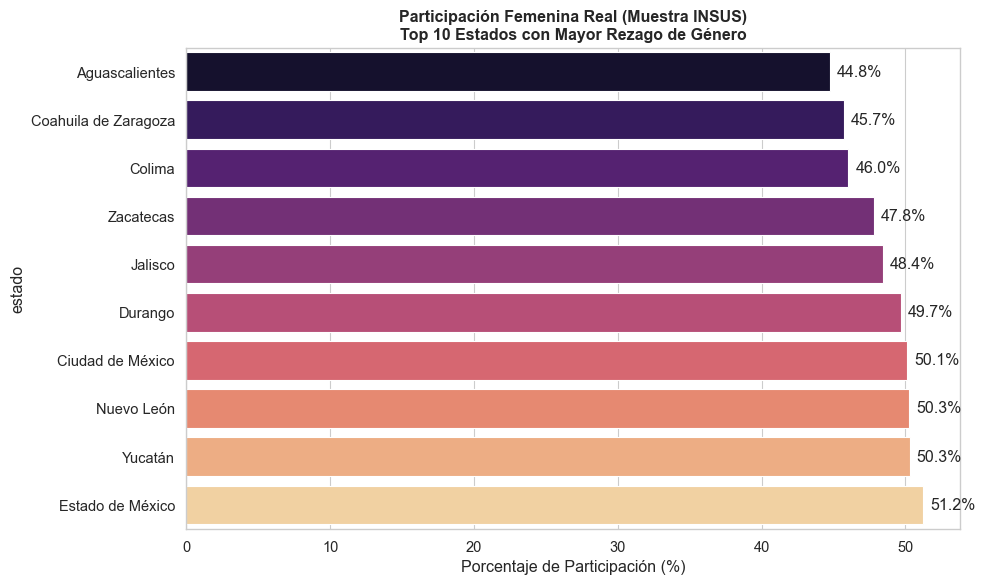

In [15]:
# --- CORRECCIÓN DE LA BRECHA DE GÉNERO ---
# Usamos solo el archivo consolidado pero recalculamos la métrica
df_demanda = pd.read_csv("../data/processed/demanda_municipal_consolidada.csv")

# IMPORTANTE: No dividir entre 'Total_Creditos' (que es el universo total)
# sino entre la suma de hombres y mujeres reportados en el mismo estudio (INSUS)
df_demanda['Total_INSUS'] = df_demanda['Creditos_Mujer'] + df_demanda['Creditos_Hombre']
df_demanda['estado'] = df_demanda['estado'].replace('México', 'Estado de México')
# Filtrar municipios que no tienen datos de género para evitar divisiones por cero
df_genero_real = df_demanda[df_demanda['Total_INSUS'] > 0].copy()

# Recalcular el porcentaje real
df_genero_real['Pct_Mujeres_Real'] = (df_genero_real['Creditos_Mujer'] / df_genero_real['Total_INSUS']) * 100

# Agrupar por estado para el gráfico
resumen_estado = df_genero_real.groupby('estado')['Pct_Mujeres_Real'].mean().reset_index()
top_peores = resumen_estado.sort_values('Pct_Mujeres_Real').head(10)

# Graficar de nuevo
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Pct_Mujeres_Real', y='estado', data=top_peores, palette="magma")
plt.title('Participación Femenina Real (Muestra INSUS)\nTop 10 Estados con Mayor Rezago de Género', weight='bold')
plt.xlabel('Porcentaje de Participación (%)')
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%', padding=5)

plt.show()

C:\Users\cesar\AppData\Local\Temp\ipykernel_40544\3121250270.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='pcu', y='Total_Competencia_Formal', data=df_pcu_nacional,


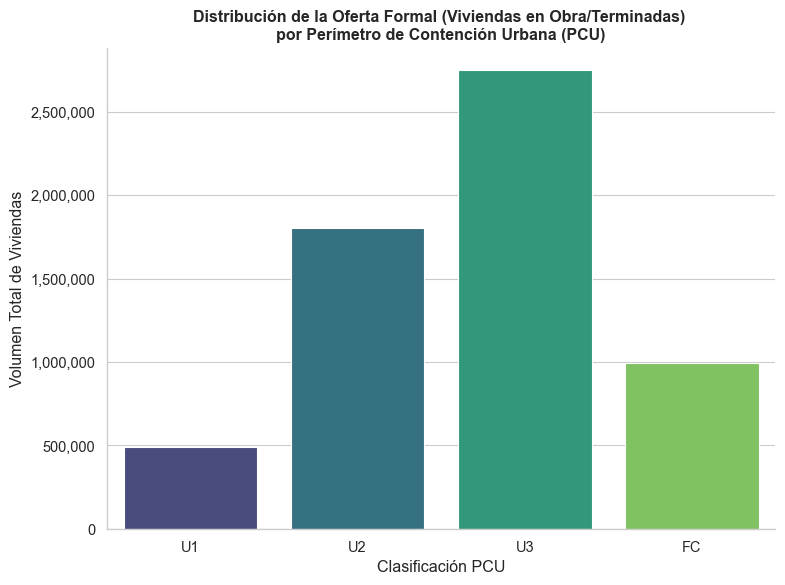

In [16]:
# 1. Agrupar la oferta formal por PCU a nivel nacional
df_pcu_nacional = df_formal.groupby('pcu')['Total_Competencia_Formal'].sum().reset_index()

# 2. Filtrar solo los PCU válidos (U1, U2, U3, FC) para evitar ruido
pcu_validos = ['U1', 'U2', 'U3', 'FC']
df_pcu_nacional = df_pcu_nacional[df_pcu_nacional['pcu'].isin(pcu_validos)]

# 3. Graficar
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='pcu', y='Total_Competencia_Formal', data=df_pcu_nacional, 
                 order=['U1', 'U2', 'U3', 'FC'], palette="viridis")

plt.title('Distribución de la Oferta Formal (Viviendas en Obra/Terminadas) \npor Perímetro de Contención Urbana (PCU)', weight='bold')
plt.xlabel('Clasificación PCU')
plt.ylabel('Volumen Total de Viviendas')

# Formatear el eje Y con comas para miles/millones
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

sns.despine()
plt.savefig(os.path.join(DIR_GRAFICOS, "distribucion_oferta_pcu.pdf"), bbox_inches='tight')
plt.show()